# DATA266 Lab 1 - Task 3
## CycleGAN, Monet <-> photo (zoheb_waghu)

Skeleton only: setup and data checks work; every section marked **YOUR CODE** is yours to design
and write (brief section 8 - architecture and analysis must be your own, defended at the viva).

Convention (instructor's evaluator): **A = Monet**, **B = photo**. `pred_A2B` = Monet->Photo,
`pred_B2A` = Photo->Monet. The Kaggle submission is Photo->Monet = `pred_B2A`.

Everything is driven by `configs/cyclegan_baseline.yaml`; change values there, not in cells.

In [1]:
import json, sys
from pathlib import Path
def _find_root(start=None):
    p = (start or Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand/'common'/'config.py').exists() and (cand/'requirements.txt').exists():
            return cand
    raise RuntimeError('repo root not found from %s' % p)
ROOT = _find_root()
sys.path.insert(0, str(ROOT))
import torch
from common.config import load_config, set_seed, get_device, describe_hardware
from common.run_logger import RunLogger, new_run_id

MEMBER = ROOT/'task3_gan/zoheb_waghu'
cfg = load_config(MEMBER/'configs/cyclegan_baseline.yaml')
set_seed(cfg['run']['seed'])
device = get_device(cfg['run']['device'])
print('torch', torch.__version__, '|', device, '|', describe_hardware(device).get('gpu_name', 'cpu'))

torch 2.5.1+cu124 | cuda | NVIDIA GeForce RTX 4090


## 1. Data (unpaired domains)

In [2]:
from PIL import Image
for name in ('domain_a_dir', 'domain_b_dir'):
    d = Path(cfg['data'][name]); files = sorted(d.glob('*.jpg'))
    print(f"{name}: {d.name:<10} {len(files):>5} images, size {Image.open(files[0]).size}")
# A = Monet (300), B = photo (7038). cfg['data']['epoch_definition'] says which domain sets an epoch.

domain_a_dir: monet_jpg    300 images, size (256, 256)
domain_b_dir: photo_jpg   7038 images, size (256, 256)


### 1.1 Dataset and dataloaders

**YOUR CODE** - load, augment (`load_size`, `image_size`, `random_flip` are in the config), batch.

In [3]:
import inspect
sys.path.insert(0, str(MEMBER/'src'))
import data as t3data
print(inspect.getsource(t3data.load_domain)); print(inspect.getsource(t3data.random_batch)); print(inspect.getsource(t3data.ImagePool))

def load_domain(folder, load_size: int, device) -> tuple:
    """-> (uint8 tensor (N, 3, load_size, load_size) on `device`, sorted file names)."""
    files = sorted(Path(folder).glob("*.jpg"))
    if not files:
        raise FileNotFoundError(f"no .jpg images in {folder}")
    arr = np.stack([np.asarray(Image.open(p).convert("RGB").resize((load_size, load_size), Image.BICUBIC))
                    for p in files])
    return torch.from_numpy(arr).permute(0, 3, 1, 2).contiguous().to(device), [p.name for p in files]

def random_batch(imgs: torch.Tensor, idx, size: int, flip: bool) -> torch.Tensor:
    """Random crop (+ flip) of the chosen images, float in [-1, 1]."""
    span = imgs.shape[-1] - size + 1
    out = []
    for i in idx:
        y, x = random.randrange(span), random.randrange(span)
        t = imgs[i, :, y:y + size, x:x + size]
        out.append(t.flip(-1) if flip and random.random() < 0.5 else t)
    return torch.stack(out).float().div(127.5).sub(1.0)

class ImagePool:
  

## 2. Model

### 2.1 Generators (G_AB, G_BA)

**YOUR CODE** + why this design (`model:` in the config).

In [4]:
import model as t3model
print(inspect.getsource(t3model.ResBlock)); print(inspect.getsource(t3model.ResnetGenerator))

class ResBlock(nn.Module):
    """x + (pad, conv3, IN, ReLU, pad, conv3, IN)(x). Reflection padding avoids border artifacts."""

    def __init__(self, dim: int) -> None:
        super().__init__()
        self.body = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(dim, dim, 3), nn.InstanceNorm2d(dim), nn.ReLU(True),
            nn.ReflectionPad2d(1), nn.Conv2d(dim, dim, 3), nn.InstanceNorm2d(dim))

    def forward(self, x):
        return x + self.body(x)

class ResnetGenerator(nn.Module):
    """7x7 conv -> 2 stride-2 downsamples -> N residual blocks -> 2 transposed-conv upsamples
    -> 7x7 conv -> tanh. Output in [-1, 1], same size as the input."""

    def __init__(self, filters: int, blocks: int) -> None:
        super().__init__()
        f = filters
        layers = [nn.ReflectionPad2d(3), nn.Conv2d(3, f, 7), nn.InstanceNorm2d(f), nn.ReLU(True)]
        for i in range(2):                                      # f -> 2f -> 4f
            c = f * 2 ** i
            lay

### 2.2 Discriminators (D_A, D_B)

**YOUR CODE**

In [5]:
print(inspect.getsource(t3model.PatchDiscriminator))

class PatchDiscriminator(nn.Module):
    """`layers` stride-2 4x4 convs (channels doubling, capped at 8x), then a stride-1 conv, then a
    1-channel map of real/fake scores. layers=3 gives a 70x70 receptive field."""

    def __init__(self, filters: int, layers: int) -> None:
        super().__init__()
        f = filters
        seq = [nn.Conv2d(3, f, 4, 2, 1), nn.LeakyReLU(0.2, True)]
        mult = 1
        for n in range(1, layers):
            prev, mult = mult, min(2 ** n, 8)
            seq += [nn.Conv2d(f * prev, f * mult, 4, 2, 1), nn.InstanceNorm2d(f * mult),
                    nn.LeakyReLU(0.2, True)]
        prev, mult = mult, min(2 ** layers, 8)
        seq += [nn.Conv2d(f * prev, f * mult, 4, 1, 1), nn.InstanceNorm2d(f * mult),
                nn.LeakyReLU(0.2, True), nn.Conv2d(f * mult, 1, 4, 1, 1)]
        self.net = nn.Sequential(*seq)

    def forward(self, x):
        return self.net(x)



### 2.3 Losses

**YOUR CODE** - adversarial, cycle-consistency, identity (`loss:` in the config), image pool if used.

In [6]:
# Losses live in src/train.py (main loop). Values come from cfg['loss']:
import yaml
print(yaml.safe_dump({'loss': cfg['loss'], 'gan_mode_note': 'lsgan = MSE against 1 (real) / 0 (fake)'}, sort_keys=False))
nets = t3model.build_networks(cfg)
print({k: f"{sum(p.numel() for p in v.parameters()):,}" for k, v in nets.items()})

loss:
  gan_mode: lsgan
  lambda_cycle_a: 10.0
  lambda_cycle_b: 10.0
  lambda_identity: 0.5
  image_pool_size: 50
gan_mode_note: lsgan = MSE against 1 (real) / 0 (fake)



{'g_ab': '11,378,179', 'g_ba': '11,378,179', 'd_a': '2,764,737', 'd_b': '2,764,737'}

## 3. Training

**YOUR CODE.** Log through `RunLogger` so the evaluator can read your run. The evaluator expects
these events in `reproducibility/raw_logs/zoheb_waghu/task3_gan/<run_id>.jsonl` (missing ones are
recorded as NOT_MEASURED):

```python
log = RunLogger(cfg['paths']['log_dir'], run_id, config=cfg, hardware=describe_hardware(device))
log.event('step', g_loss=..., d_loss=..., cycle_loss=..., identity_loss=..., grad_norm=...)  # every log_interval_steps
log.event('nan')                                                                              # once per non-finite step
log.event('train_summary', param_count=..., train_seconds=..., images_per_sec=..., peak_memory_gb=...)
log.close(status='ok')
```
Save checkpoints to `cfg['paths']['checkpoint_dir']` (gitignored) and record the file name.

In [7]:
# Training is run from the command line so it is config-driven and logged:
#   python task3_gan/zoheb_waghu/src/train.py --config task3_gan/zoheb_waghu/configs/cyclegan_baseline.yaml
# (resume: add --run-id <id> --resume <checkpoint_dir>/<id>_last.pt). Training loop source:
import train as t3train
print(inspect.getsource(t3train.main))

def main() -> int:
    ap = config_arg_parser("Task 3 - train CycleGAN")
    ap.add_argument("--max-steps", type=int, default=None)
    ap.add_argument("--resume", default=None)
    args = ap.parse_args()
    cfg = load_config(args.config)
    set_seed(cfg["run"]["seed"])
    device = get_device(cfg["run"]["device"])
    torch.backends.cudnn.benchmark = True                      # fixed input size, faster kernels
    d, m, ls, t = cfg["data"], cfg["model"], cfg["loss"], cfg["train"]
    paths = cfg["paths"]
    run_id = args.run_id or new_run_id(cfg["run"]["tag"] + ("_smoke" if args.max_steps else ""))
    log = RunLogger(paths["log_dir"], run_id, config=cfg, hardware=describe_hardware(device))
    out = Path(paths["output_dir"])
    (out / "train_samples").mkdir(parents=True, exist_ok=True)
    Path(paths["checkpoint_dir"]).mkdir(parents=True, exist_ok=True)

    try:
        imgs_a, _ = load_domain(d["domain_a_dir"], d["load_size"], device)
        imgs_b, _ = load_domain(d["domain_b

### 3.1 Loss curves and stability

**YOUR CODE** - plot to `outputs/plots/`, comment on convergence and stability.

run t3_baseline_20260929-235720 | 5630 logged steps | 0 NaN events


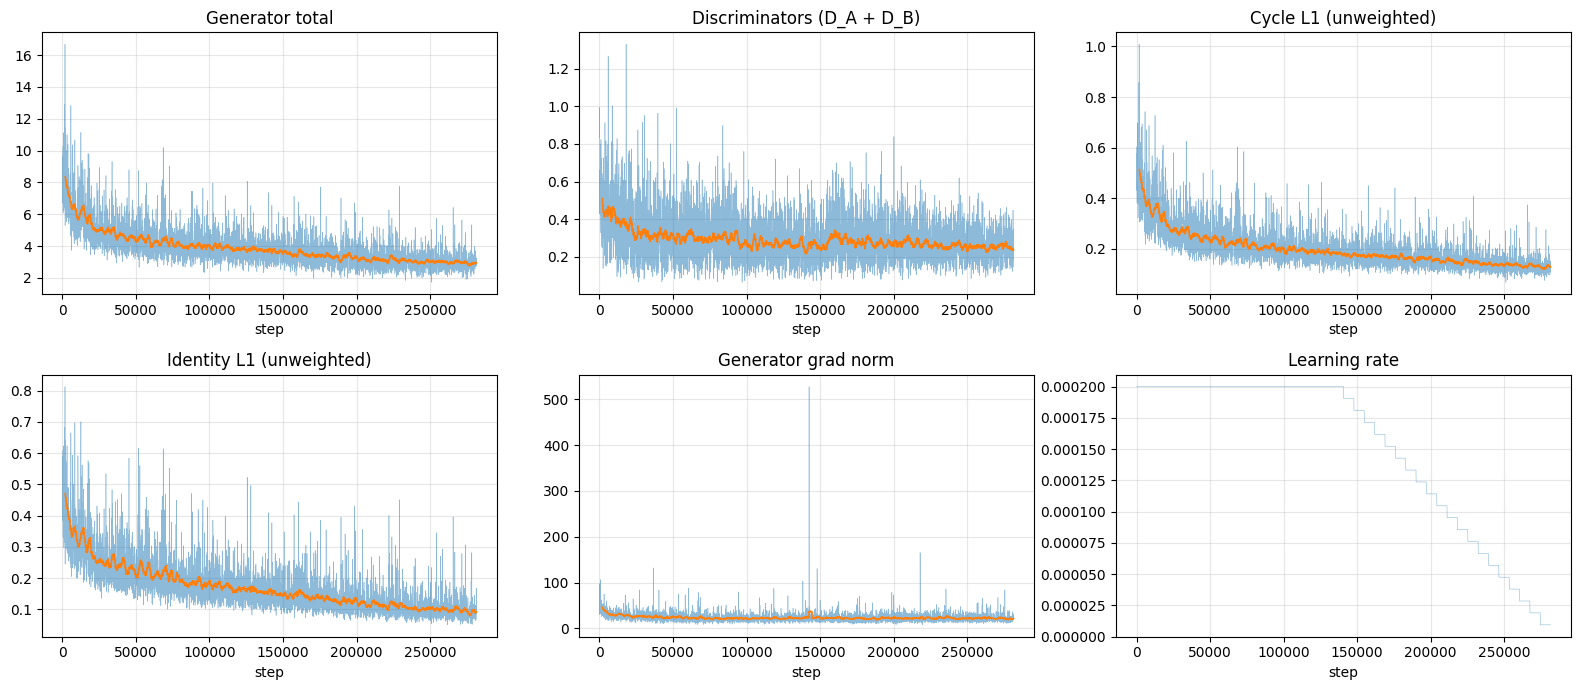

In [8]:
import matplotlib.pyplot as plt, numpy as np
logs = sorted(Path(cfg['paths']['log_dir']).glob('t3_baseline_2*.jsonl'))
runs = [p for p in logs if 'train_summary' in p.read_text(encoding='utf-8')]
LOG = runs[-1]; TRAIN_RUN_ID = LOG.stem
ev = [json.loads(l) for l in LOG.read_text(encoding='utf-8').splitlines()]
st = [e for e in ev if e['kind'] == 'step']
print('run', TRAIN_RUN_ID, '|', len(st), 'logged steps |', sum(e['kind'] == 'nan' for e in ev), 'NaN events')
fig, ax = plt.subplots(2, 3, figsize=(16, 7)); x = [e['step'] for e in st]
sm = lambda v, k=40: np.convolve(v, np.ones(k) / k, mode='valid')
for a, key, title in zip(ax.flat, ('g_loss', 'd_loss', 'cycle_loss', 'identity_loss', 'grad_norm', 'lr'),
                         ('Generator total', 'Discriminators (D_A + D_B)', 'Cycle L1 (unweighted)', 'Identity L1 (unweighted)', 'Generator grad norm', 'Learning rate')):
    v = [e[key] for e in st]; a.plot(x, v, lw=.4, alpha=.5)
    if key != 'lr' and len(v) > 40: a.plot(x[39:], sm(v), lw=1.2)
    a.set(title=title, xlabel='step'); a.grid(alpha=.3)
fig.tight_layout(); (MEMBER/'outputs/plots').mkdir(parents=True, exist_ok=True)
fig.savefig(MEMBER/f'outputs/plots/training_curves_{TRAIN_RUN_ID}.png', dpi=140)

## 4. Inference

**YOUR CODE.** Write into `cfg['paths']['output_dir']`, every file **named like its source image**:

| Folder | Contents |
|---|---|
| `pred_A2B/` | Monet -> Photo, from `monet_jpg/` |
| `pred_B2A/` | Photo -> Monet, from `photo_jpg/` (all 7038 for the Kaggle submission) |
| `cycle_A/` | Monet -> Photo -> Monet reconstruction |
| `cycle_B/` | Photo -> Monet -> Photo reconstruction |

Submission images must be the direct output of your own trained CycleGAN - no editing, no
pretrained image models (brief, leaderboard integrity).

In [9]:
import subprocess
OUT = Path(cfg['paths']['output_dir']); CK_DIR = Path(cfg['paths']['checkpoint_dir'])
# fp32 _final.pt stays local (108 MB); the repo carries an fp16 copy of the two generators (43 MB,
# FID within 0.11 of fp32). Inference uses whichever is present.
CHECKPOINT = next(n for n in (f'{TRAIN_RUN_ID}_final.pt', f'{TRAIN_RUN_ID}_generators_fp16.pt') if (CK_DIR/n).exists())
have = {d: len(list((OUT/d).glob('*.jpg'))) for d in ('pred_A2B', 'pred_B2A', 'cycle_A', 'cycle_B')}
if min(have['pred_A2B'], have['cycle_A']) < 300 or min(have['pred_B2A'], have['cycle_B']) < 7038:
    subprocess.run([sys.executable, str(MEMBER/'src/infer.py'), '--config', str(MEMBER/'configs/cyclegan_baseline.yaml'),
                    '--checkpoint', CHECKPOINT], check=True)
    have = {d: len(list((OUT/d).glob('*.jpg'))) for d in have}
else:
    print('translations already generated - not regenerated, so they stay identical to the evaluated set')
print('checkpoint:', CHECKPOINT); print(have)

translations already generated - not regenerated, so they stay identical to the evaluated set
checkpoint: t3_baseline_20260929-235720_final.pt
{'pred_A2B': 300, 'pred_B2A': 7038, 'cycle_A': 300, 'cycle_B': 7038}


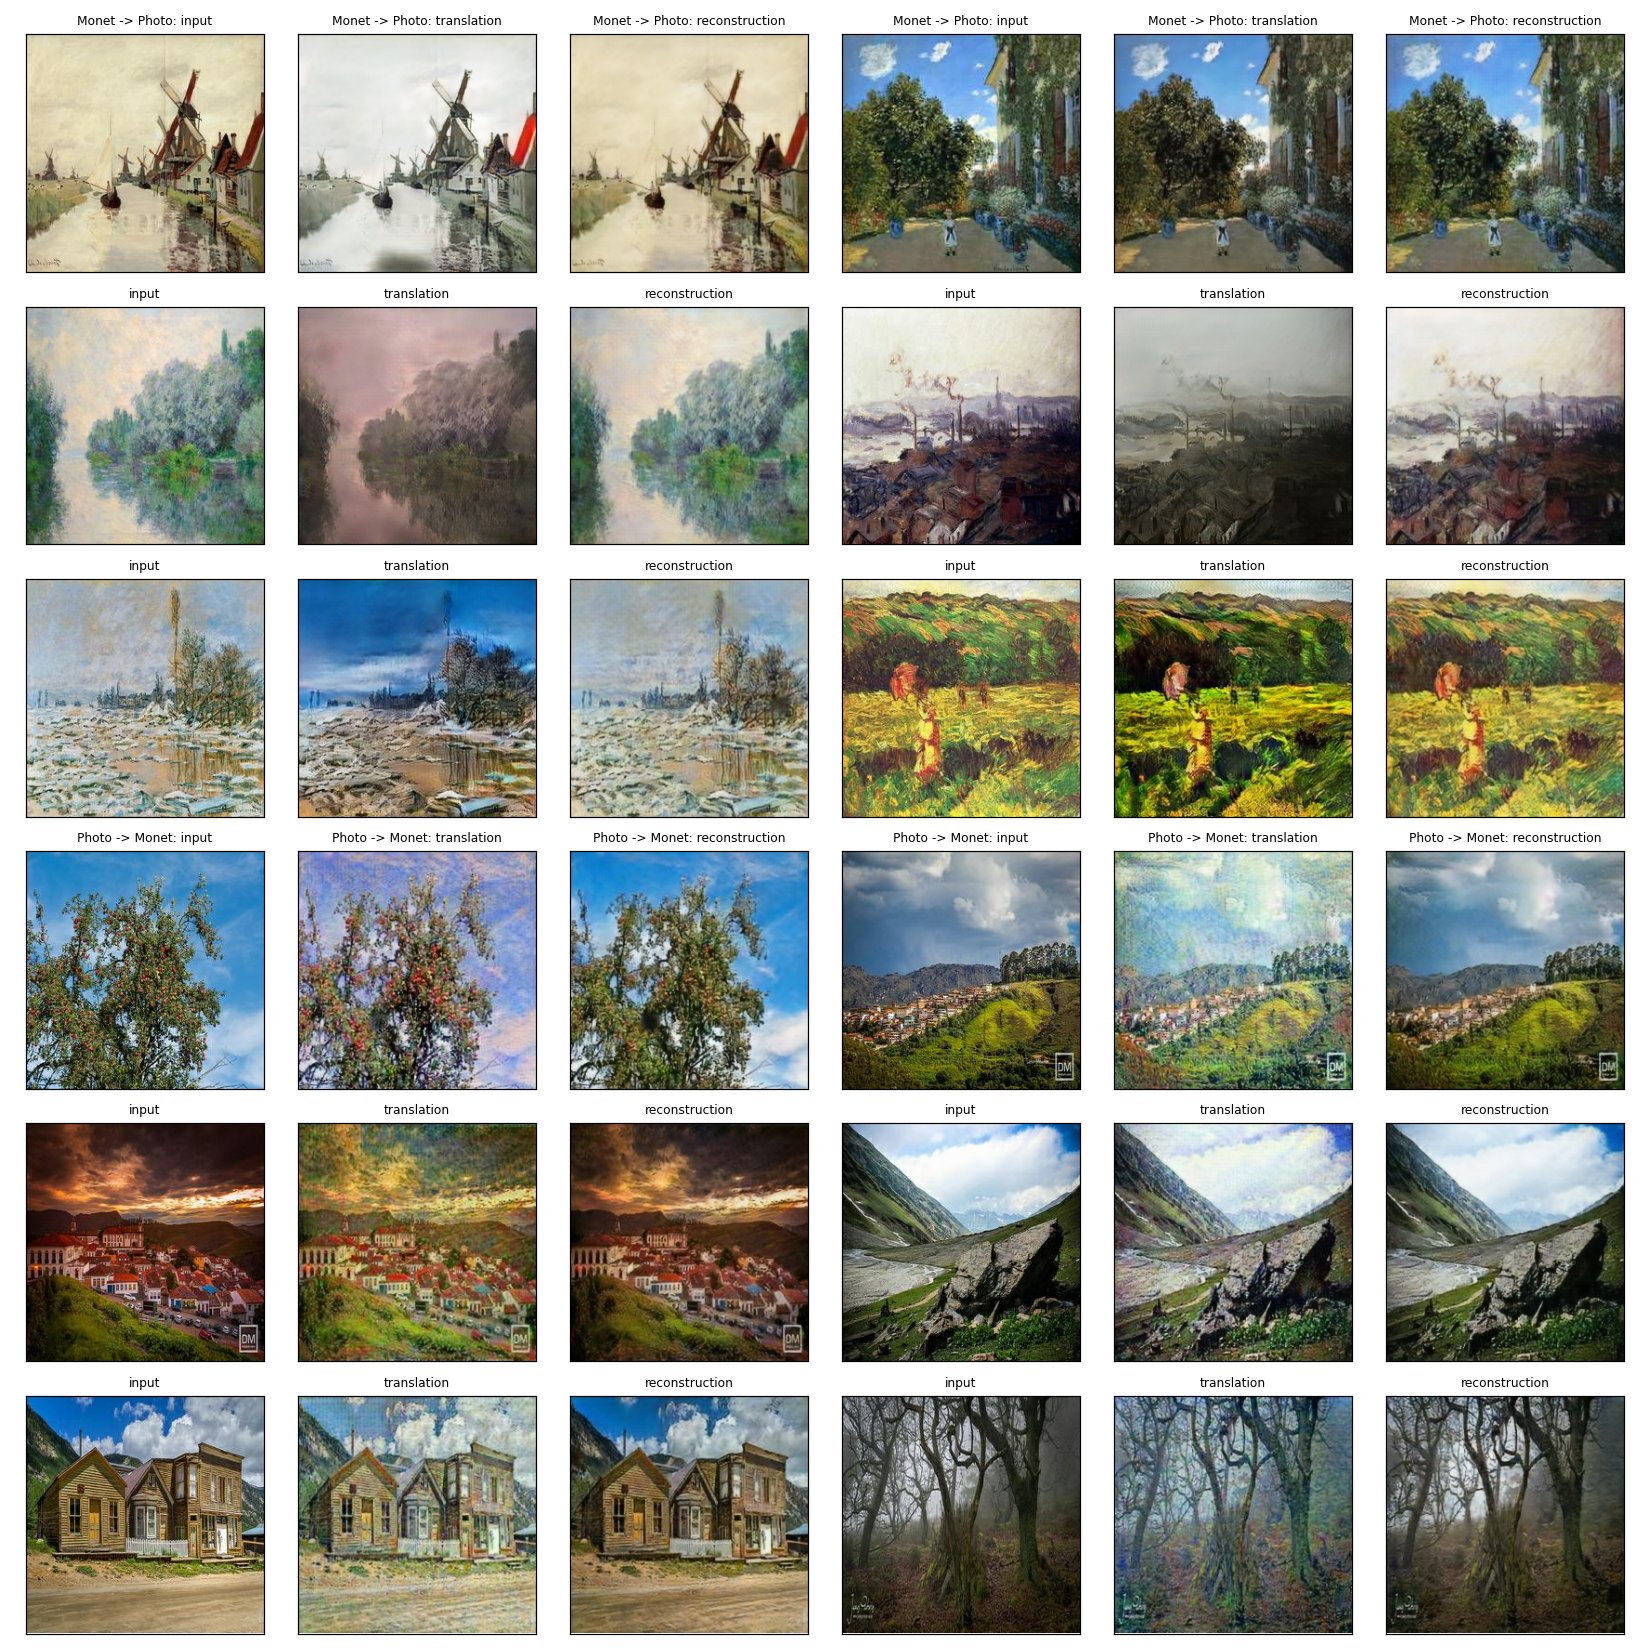

In [10]:
# Example translations: fixed random picks (seed from config), source | translation | cycle reconstruction
import random
from PIL import Image as PILImage
rng = random.Random(cfg['run']['seed'])
rows = [('Monet -> Photo', cfg['data']['domain_a_dir'], 'pred_A2B', 'cycle_A'),
        ('Photo -> Monet', cfg['data']['domain_b_dir'], 'pred_B2A', 'cycle_B')]
fig, ax = plt.subplots(6, 6, figsize=(15, 15))
for r, (title, src, pred, cyc) in enumerate(rows):
    names = rng.sample(sorted(p.name for p in (OUT/pred).glob('*.jpg')), 6)
    for j, n in enumerate(names):
        for k, (folder, label) in enumerate(((Path(src), 'input'), (OUT/pred, 'translation'), (OUT/cyc, 'reconstruction'))):
            a = ax[(j // 2) + 3 * r, (j % 2) * 3 + k]
            a.imshow(PILImage.open(folder/n)); a.set_xticks([]); a.set_yticks([])
            a.set_title(f'{title}: {label}' if j < 2 else label, fontsize=8)
fig.tight_layout(); fig.savefig(MEMBER/'outputs/plots/translation_examples.jpg', dpi=110, pil_kwargs={'quality': 85})
plt.close(fig); from IPython.display import Image as ShowImage, display; display(ShowImage(filename=str(MEMBER/'outputs/plots/translation_examples.jpg')))

## 5. Evaluation (tooling provided)

In [11]:
cmd = [sys.executable, str(MEMBER/'evaluate_local.py'), 'metrics',
       '--config', str(MEMBER/'configs/cyclegan_baseline.yaml'),
       '--train-run-id', TRAIN_RUN_ID, '--checkpoint', CHECKPOINT]   # add '--zip' for the Kaggle images.zip
# subprocess.run(cmd, check=True)   # uncomment to run; appends 2 rows (A2B, B2A) to full_metrics_report.csv

In [12]:
import pandas as pd
pd.read_csv(MEMBER/'full_metrics_report.csv')

,direction,run_id,checkpoint,fid,kid,gen_precision,gen_recall,density,coverage,cycle_l1,...,human_audit_artifacts,inter_rater_kappa,parameter_count,training_time_s,images_per_sec,peak_memory_gb,kaggle_public,kaggle_private,leaderboard_rank,hardware
0,A2B,t3_baseline_20260929-235720,t3_baseline_20260929-235720_final.pt,103.19668,0.01818,0.70333,0.48,1.01267,0.89667,0.03315,...,NOT_MEASURED,NOT_MEASURED,28285832,24082.61,11.69,12.7792,NOT_MEASURED,NOT_MEASURED,NOT_MEASURED,NVIDIA GeForce RTX 4090 / cuda / torch 2.5.1+c...
1,B2A,t3_baseline_20260929-235720,t3_baseline_20260929-235720_final.pt,98.85495,0.00762,0.50667,0.68,0.43333,0.69000,0.03984,...,NOT_MEASURED,NOT_MEASURED,28285832,24082.61,11.69,12.7792,NOT_MEASURED,NOT_MEASURED,NOT_MEASURED,NVIDIA GeForce RTX 4090 / cuda / torch 2.5.1+c...


### 5.1 Human audit (30 blinded samples, 2 raters)

`python task3_gan/zoheb_waghu/evaluate_local.py audit-sheet --config task3_gan/zoheb_waghu/configs/cyclegan_baseline.yaml`
builds `outputs/human_audit/` and a ratings template. Raters see only that folder; re-run the
`metrics` command after rating to fold in the scores and Cohen's kappa.

### 5.2 Failure-case candidates (selected by measurement, judged by you)

Per-image LPIPS (input vs translation) and cycle L1 on the evaluated set (first 300 per direction).
Three mechanical picks per direction: **least changed** (lowest LPIPS - the translation barely
departs from the input), **most changed** (highest LPIPS - content most altered), **worst cycle**
(highest cycle L1 - reconstruction furthest from the input). Assigning a failure type and
explaining it is the write-up's job, in `failure_analysis.md`.

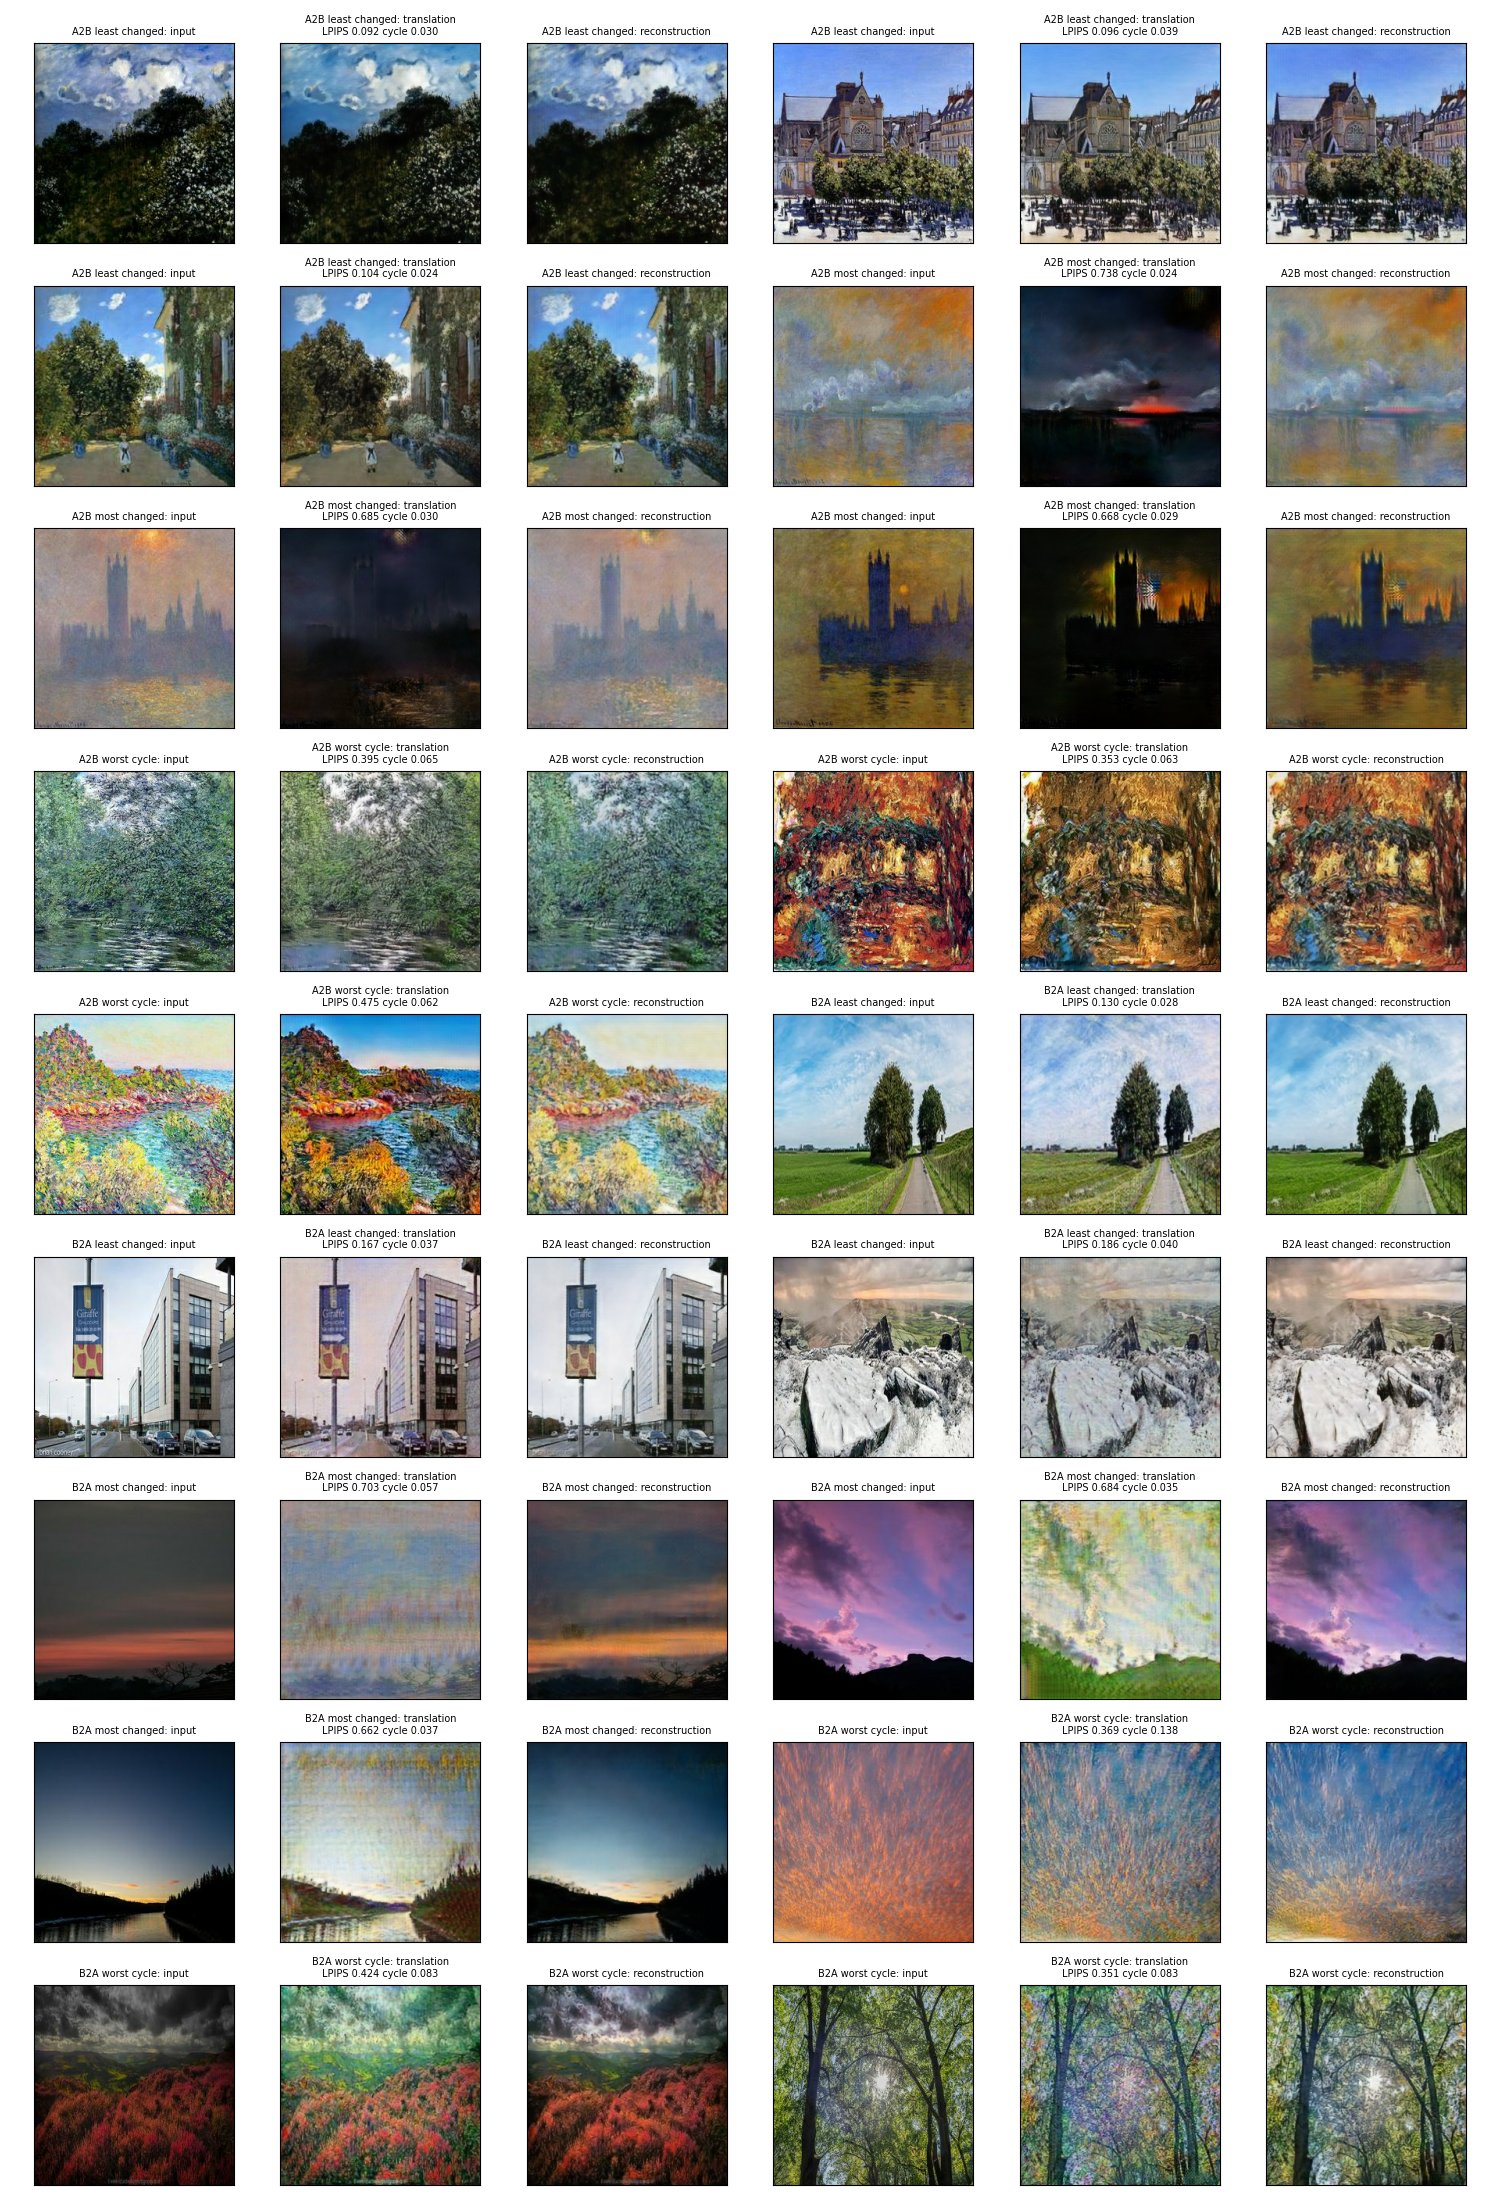

direction            A2B       B2A
lpips    count  300.0000  300.0000
         mean     0.3545    0.3783
         std      0.1062    0.1078
         min      0.0923    0.1299
         25%      0.2808    0.3037
         50%      0.3471    0.3550
         75%      0.4162    0.4421
         max      0.7378    0.7026
cycle_l1 count  300.0000  300.0000
         mean     0.0337    0.0404
         std      0.0082    0.0131
         min      0.0167    0.0164
         25%      0.0280    0.0322
         50%      0.0324    0.0378
         75%      0.0383    0.0459
         max      0.0650    0.1378


,direction,category,file,lpips,cycle_l1
0,A2B,least changed,a202b1b200.jpg,0.092270,0.030050
1,A2B,least changed,815624563e.jpg,0.095792,0.038721
2,A2B,least changed,99d94af5dd.jpg,0.104467,0.023901
3,A2B,most changed,9d9a4fccfb.jpg,0.737814,0.024393
4,A2B,most changed,ede9769cb3.jpg,0.684828,0.029932
5,A2B,most changed,b1ea5d5a7d.jpg,0.668122,0.028503
6,A2B,worst cycle,4f7e01f097.jpg,0.395494,0.064964
7,A2B,worst cycle,6782e7cb2a.jpg,0.353486,0.062817
8,A2B,worst cycle,a619072f82.jpg,0.474511,0.061614
9,B2A,least changed,03c9f3d584.jpg,0.129903,0.027897


In [13]:
import warnings; warnings.filterwarnings('ignore')   # library deprecation notices print local install paths
import lpips, numpy as np, pandas as pd, torchvision.transforms as TT
lp = lpips.LPIPS(net=cfg['eval']['lpips_net'], verbose=False).to(device).eval()
to_t = lambda f: (TT.ToTensor()(PILImage.open(f).convert('RGB')) * 2 - 1).unsqueeze(0).to(device)
load = lambda f: np.asarray(PILImage.open(f).convert('RGB'), dtype=np.float32) / 255
recs = []
with torch.no_grad():
    for d, src, pred, cyc in (('A2B', cfg['data']['domain_a_dir'], 'pred_A2B', 'cycle_A'),
                              ('B2A', cfg['data']['domain_b_dir'], 'pred_B2A', 'cycle_B')):
        for f in sorted((OUT/pred).glob('*.jpg'))[:cfg['eval']['n_eval']]:
            s = Path(src)/f.name
            recs.append({'direction': d, 'file': f.name, 'lpips': lp(to_t(s), to_t(f)).item(),
                         'cycle_l1': float(np.abs(load(s) - load(OUT/cyc/f.name)).mean())})
per_img = pd.DataFrame(recs)
picks = []
for d, g in per_img.groupby('direction'):
    for cat, sub in (('least changed', g.nsmallest(3, 'lpips')), ('most changed', g.nlargest(3, 'lpips')),
                     ('worst cycle', g.nlargest(3, 'cycle_l1'))):
        picks += [dict(r, category=cat) for r in sub.to_dict('records')]
cand = pd.DataFrame(picks)[['direction', 'category', 'file', 'lpips', 'cycle_l1']]
cand.to_csv(OUT/'failure_candidates.csv', index=False)
src_of = {'A2B': (cfg['data']['domain_a_dir'], 'pred_A2B', 'cycle_A'), 'B2A': (cfg['data']['domain_b_dir'], 'pred_B2A', 'cycle_B')}
fig, ax = plt.subplots(9, 6, figsize=(15, 22))
for n, r in enumerate(cand.itertuples()):
    src, pred, cyc = src_of[r.direction]
    for k, folder in enumerate((Path(src), OUT/pred, OUT/cyc)):
        a = ax[n // 2, (n % 2) * 3 + k]; a.imshow(PILImage.open(folder/r.file)); a.set_xticks([]); a.set_yticks([])
        a.set_title(f'{r.direction} {r.category}: ' + ('input', 'translation', 'reconstruction')[k] +
                    (f'\nLPIPS {r.lpips:.3f} cycle {r.cycle_l1:.3f}' if k == 1 else ''), fontsize=7)
fig.tight_layout(); fig.savefig(MEMBER/'outputs/plots/failure_candidates.jpg', dpi=100, pil_kwargs={'quality': 85})
plt.close(fig); from IPython.display import Image as ShowImage, display; display(ShowImage(filename=str(MEMBER/'outputs/plots/failure_candidates.jpg')))
print(per_img.groupby('direction')[['lpips', 'cycle_l1']].describe().round(4).T); cand

## 6. Analysis

**YOUR CODE / YOUR WORDS** - visual quality, cycle consistency, training stability, shortcomings.
Then fill `results.md` and `failure_analysis.md`.